# Storage & swing product valuation

Price several deals in one pass, compare them side by side, and get the monthly hedge.

**How to use:** edit **§1 Curve** and **§2 Deals**, then Run All. Everything below is output.

Deals are described in physical units — capacity in MWh, rate in MWh/day — and the model
derives its own grid from them. Conventions (signs, units, what `delta` means) are in
[docs/MODEL-CONVENTIONS.md](docs/MODEL-CONVENTIONS.md); the traps worth knowing are listed
at the bottom of this notebook.

In [1]:
import time, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import storage_model as sm

pd.set_option("display.width", 200, "display.max_columns", 50)
plt.rcParams.update({"figure.figsize": (13, 3.4), "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 9})
warnings.filterwarnings("ignore", category=FutureWarning)
print("ready")

ready


## 1. Curve

Pick the source and the as-of date. `csv` uses the monthly contract file; `quotes` picks the
latest quote on or before `AS_OF` out of the TTF matrix.

The curve must cover the deal window **plus one month-end** — the model carries a terminal
condition past the last exercise day. It will say so plainly if it doesn't.

curve.csv: 38 contracts, Jan-26 .. Feb-29, 22.66-28.88 EUR/MWh


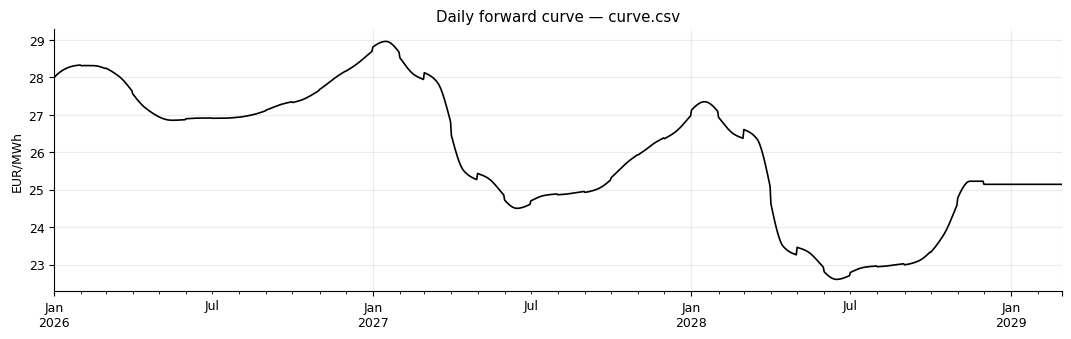

In [2]:
CURVE_SOURCE = "csv"                      # "csv"  -> curve.csv    |  "quotes" -> ttf q.xlsx
AS_OF        = pd.Timestamp("2026-01-05")  # used by "quotes" only
VAL_DATE     = pd.Timestamp("2026-01-01")  # discounting/valuation date for every deal


def load_curve(source=CURVE_SOURCE, as_of=AS_OF, curve_start=VAL_DATE):
    if source == "csv":
        c = pd.read_csv("curve.csv")
        c["contractStart"] = pd.to_datetime(c["contractStart"], format="mixed")
        c["contractEnd"]   = pd.to_datetime(c["contractEnd"],   format="mixed")
        return c.sort_values("contractStart").reset_index(drop=True), "curve.csv"
    import re
    q = pd.read_excel("ttf q.xlsx").rename(columns=lambda c: "quote_date" if c == "Unnamed: 0" else c)
    q = q.rename(columns={q.columns[0]: "quote_date"}).dropna(subset=["quote_date"])
    q["quote_date"] = pd.to_datetime(q["quote_date"], format="mixed")
    q = q.sort_values("quote_date").reset_index(drop=True)
    cols = sorted([c for c in q.columns if re.fullmatch(r"TTFc\d+", str(c))],
                  key=lambda c: int(re.search(r"\d+", str(c)).group()))
    row = sm.quote_row_for_fd_date(q, cols, as_of)
    return (sm.curve_df_for_storage(row, cols, curve_start=curve_start, include_da=True),
            f"ttf q.xlsx @ {pd.Timestamp(row['quote_date']):%Y-%m-%d}")


CURVE, CURVE_LABEL = load_curve()
print(f"{CURVE_LABEL}: {len(CURVE)} contracts, "
      f"{CURVE['contractStart'].min():%b-%y} .. {CURVE['contractEnd'].max():%b-%y}, "
      f"{CURVE['value'].min():.2f}-{CURVE['value'].max():.2f} EUR/MWh")

_daily = sm.smoothen_curve(sm.map_curve_to_dates(
    pd.date_range(CURVE["contractStart"].min(), CURVE["contractEnd"].max(), freq="D"), CURVE))
ax = _daily.plot(color="black", lw=1.2, title=f"Daily forward curve — {CURVE_LABEL}")
ax.set_ylabel("EUR/MWh"); plt.show()

## 2. Deals

One dict per deal. Only `name`, `product_type` and the dates are required — everything else
falls back to `DEFAULTS`.

| Field | Meaning |
|---|---|
| `product_type` | `put_swing` (must buy), `call_swing` (may sell), `storage` (buy and sell) |
| `capacity_mwh` | total volume over the deal |
| `daily_max` | maximum MWh per day |
| `clips_per_day` | how finely a day is split; the clip is `daily_max / clips_per_day` |
| `vol`, `sMR` | annualised log-vol, mean reversion per year |
| `strike` | call swing only: fixed exercise price, `0` = strike at the forward |
| `inj_rate` / `wdr_rate` | storage only: **clips per day** in and out. Leave out for symmetric |
| `inj_cost` / `wdr_cost` | storage only: EUR/MWh each way |

In [3]:
DEFAULTS = dict(
    valDate       = VAL_DATE,
    vol           = 0.50,   # annualised
    sMR           = 1.0,    # per year
    n_p_full      = 30,     # price-tree half-width; see the convergence check in section 6
    run_intrinsic = True,   # False is ~2x faster but gives no intrinsic/extrinsic split
    clips_per_day = 1,
)

DEALS = [
    dict(name="Put swing 2027",
         product_type="put_swing",
         storageStart="2027-01-01", storageEnd="2027-12-31",
         capacity_mwh=30_000, daily_max=1_000),

    dict(name="Call swing Apr-Sep 26",
         product_type="call_swing",
         storageStart="2026-04-01", storageEnd="2026-09-30",
         capacity_mwh=30_000, daily_max=1_000, strike=0.0),

    dict(name="Call swing K=28",
         product_type="call_swing",
         storageStart="2026-04-01", storageEnd="2026-09-30",
         capacity_mwh=30_000, daily_max=1_000, strike=28.0),

    dict(name="Storage 26/27 symmetric",
         product_type="storage",
         storageStart="2026-04-01", storageEnd="2027-03-31",
         capacity_mwh=60_000, daily_max=1_000,
         inj_cost=0.5, wdr_cost=0.5),

    dict(name="Storage 26/27 fast out",
         product_type="storage",
         storageStart="2026-04-01", storageEnd="2027-03-31",
         capacity_mwh=60_000, daily_max=1_000, clips_per_day=3,
         inj_rate=1, wdr_rate=3,          # slow in, fast out (clips/day)
         inj_cost=0.5, wdr_cost=0.5),
]

pd.DataFrame([{k: d.get(k) for k in
               ("name", "product_type", "storageStart", "storageEnd",
                "capacity_mwh", "daily_max", "strike", "inj_rate", "wdr_rate")}
              for d in DEALS]).fillna("")

,name,product_type,storageStart,storageEnd,capacity_mwh,daily_max,strike,inj_rate,wdr_rate
0,Put swing 2027,put_swing,2027-01-01,2027-12-31,30000,1000,,,
1,Call swing Apr-Sep 26,call_swing,2026-04-01,2026-09-30,30000,1000,0.0,,
2,Call swing K=28,call_swing,2026-04-01,2026-09-30,30000,1000,28.0,,
3,Storage 26/27 symmetric,storage,2026-04-01,2027-03-31,60000,1000,,,
4,Storage 26/27 fast out,storage,2026-04-01,2027-03-31,60000,1000,,1.0,3.0


## 3. Run

Each deal is priced independently, and a failure is reported rather than raised — one bad
deal will not stop the rest. Two checks run on every result:

- **volume** — gross MWh injected and withdrawn. For storage these differ: `exp_ex` is a
  *net* daily figure, and on the same date some price states inject while others withdraw.
- **invariant** — the reported hedge must reprice the contract:

  `V0 = sum_i DF_i * delta_i * fwd_i  -  sum_i DF_i * (inj_cost_i * injected_i + wdr_cost_i * withdrawn_i)`

  The cost term matters: a strike or an injection/withdrawal cost is a fixed cash amount
  that does not scale with the price level, so the simpler `sum(DF*delta*fwd) == V0` holds
  only for a zero-cost, zero-strike deal. With the cost term this closes to ~1e-15 for every
  product type.

In [4]:
def price(deal, curve=None):
    # Value one deal. Returns (Storage, result dict, diagnostics).
    params = {**DEFAULTS, **{k: v for k, v in deal.items() if k != "name"}}
    t0 = time.perf_counter()
    s, r = sm.run_valuation(CURVE if curve is None else curve, params)
    secs = time.perf_counter() - t0

    n  = s.n_t
    dl = np.asarray(s.delta[:n]); df = s.d_curve[:n]
    v0 = float(s.v[0, s.n_p, s.initial_state])

    # Gross flows: exp_ex is net per day, so split the signed MWh by direction.
    moved = s.prob[:n] * s.strat[:n] * s.v_step
    injected  = np.clip(moved, 0, None).sum(axis=(1, 2))
    withdrawn = -np.clip(moved, None, 0).sum(axis=(1, 2))

    cash = np.dot(df, np.asarray(s.i_cost)[:n] * injected
                      + np.asarray(s.w_cost)[:n] * withdrawn)
    repriced = float(np.dot(df * dl, s.fwd) - cash)
    ends = np.flatnonzero(s.t_p_curve[:s.n_op] > -1e8)

    diag = dict(
        v0=v0,
        injected_mwh=float(injected.sum()), withdrawn_mwh=float(withdrawn.sum()),
        volume_mwh=float(injected.sum() + withdrawn.sum()),
        delta_mwh=float(dl.sum()),
        invariant=abs(repriced - v0) / max(abs(v0), 1.0),
        v_step=s.v_step, n_states=s.n_states, clips_per_day=s.clips_per_day,
        starts=s.initial_state, ends=ends.tolist(), secs=secs,
    )
    return s, r, diag


RESULTS = {}
for d in DEALS:
    try:
        RESULTS[d["name"]] = price(d)
        g = RESULTS[d["name"]][2]
        print(f"  OK    {d['name']:26s} {g['secs']:5.1f}s   value {g['v0']:>14,.0f} EUR")
    except Exception as e:
        print(f"  FAIL  {d['name']:26s} {type(e).__name__}: {str(e).splitlines()[0][:90]}")
print(f"\n{len(RESULTS)}/{len(DEALS)} priced")

  OK    Put swing 2027               0.5s   value       -705,727 EUR
  OK    Call swing Apr-Sep 26        0.1s   value        846,766 EUR
  OK    Call swing K=28              0.1s   value          6,766 EUR


  OK    Storage 26/27 symmetric      0.1s   value      1,773,260 EUR


  OK    Storage 26/27 fast out       0.2s   value      1,770,267 EUR

5/5 priced


## 4. Results

`EUR/MWh` is the value per MWh actually exercised. For the swings `intrinsic` is the
seasonal spread and `extrinsic` the optionality premium, both against `flat` (the unweighted
average forward over the window); for storage they are per MWh of capacity.

In [5]:
rows = []
for name, (s, r, g) in RESULTS.items():
    deal = next(d for d in DEALS if d["name"] == name)
    rows.append({
        "deal": name,
        "type": deal["product_type"],
        "window": f"{pd.Timestamp(deal['storageStart']):%b-%y} .. {pd.Timestamp(deal['storageEnd']):%b-%y}",
        "capacity MWh": deal.get("capacity_mwh"),
        "MWh/day": deal.get("daily_max"),
        "clip MWh": g["v_step"],
        "inventory": f"{g['starts']}/{g['n_states']} -> {g['ends']}",
        "value EUR": g["v0"],
        "EUR/MWh": g["v0"] / g["volume_mwh"] if g["volume_mwh"] else np.nan,
        "flat": r["flat_metric"],
        # intrinsic = profiled - flat, but with a strike `profiled` is net of it while
        # `flat` is the raw forward average, so the difference is off by -K and means
        # nothing. extrinsic is a difference of two struck values and is fine.
        "intrinsic": np.nan if deal.get("strike") else r["intrinsic"],
        "extrinsic": r["extrinsic"],
        "total": np.nan if deal.get("strike") else r["total"],
        "injected MWh": g["injected_mwh"],
        "withdrawn MWh": g["withdrawn_mwh"],
        "invariant": g["invariant"],
        "secs": g["secs"],
    })

summary = pd.DataFrame(rows).set_index("deal")
fmt = {"capacity MWh": "{:,.0f}", "MWh/day": "{:,.0f}", "clip MWh": "{:,.0f}",
       "value EUR": "{:,.0f}", "EUR/MWh": "{:,.3f}", "flat": "{:,.3f}",
       "intrinsic": "{:,.3f}", "extrinsic": "{:,.3f}", "total": "{:,.3f}",
       "injected MWh": "{:,.0f}", "withdrawn MWh": "{:,.0f}",
       "invariant": "{:.1e}", "secs": "{:.1f}"}
display(summary.style.format(fmt, na_rep="—")
        .set_caption(f"Valued {VAL_DATE:%Y-%m-%d} off {CURVE_LABEL}"))

bad = summary[summary["invariant"] > 1e-9]
print(f"invariant holds for every deal (worst {summary['invariant'].max():.1e})" if bad.empty
      else f"INVARIANT BREACHED: {list(bad.index)} — the reported hedge does not reprice the value")
struck = [d["name"] for d in DEALS if d.get("strike")]
if struck:
    print(f"intrinsic/total blanked for {struck}: the library computes intrinsic as")
    print("profiled - flat, and with a strike those two are not on the same footing")
    print("(profiled is net of K, flat is not), so the figure is off by about -K.")
    print("Read EUR/MWh for the premium and extrinsic for the optionality.")
print("inventory column reads: start clips / grid size -> permitted end states.")
print("Note storage DEFAULTS TO STARTING FULL and must end empty; swings start at the end")
print("they need to fill. Override with initial_inv_clips / terminal_inv_clips.")

,type,window,capacity MWh,MWh/day,clip MWh,inventory,value EUR,EUR/MWh,flat,intrinsic,extrinsic,total,injected MWh,withdrawn MWh,invariant,secs
deal,,,,,,,,,,,,,,,,
Put swing 2027,put_swing,Jan-27 .. Dec-27,"30,000","1,000","1,000",0/30 -> [30],"-705,727",-23.524,26.104,1.542,1.037,2.580,"30,000",0,1.2e-15,0.5
Call swing Apr-Sep 26,call_swing,Apr-26 .. Sep-26,"30,000","1,000","1,000",30/30 -> [0],"846,766",28.226,27.024,0.314,0.887,1.201,0,"30,000",2.7e-16,0.1
Call swing K=28,call_swing,Apr-26 .. Sep-26,"30,000","1,000","1,000",30/30 -> [0],"6,766",0.226,27.024,—,0.887,—,0,"30,000",1.3e-15,0.1
Storage 26/27 symmetric,storage,Apr-26 .. Mar-27,"60,000","1,000","1,000",60/60 -> [0],"1,773,260",21.201,—,0.794,1.612,2.406,"11,820","71,820",2.6e-16,0.1
Storage 26/27 fast out,storage,Apr-26 .. Mar-27,"60,000","1,000",333,180/180 -> [0],"1,770,267",22.992,—,0.668,1.231,1.899,"8,497","68,497",1.3e-16,0.2


invariant holds for every deal (worst 1.3e-15)
intrinsic/total blanked for ['Call swing K=28']: the library computes intrinsic as
profiled - flat, and with a strike those two are not on the same footing
(profiled is net of K, flat is not), so the figure is off by about -K.
Read EUR/MWh for the premium and extrinsic for the optionality.
inventory column reads: start clips / grid size -> permitted end states.
Note storage DEFAULTS TO STARTING FULL and must end empty; swings start at the end
they need to fill. Override with initial_inv_clips / terminal_inv_clips.


## 5. Profiles and the monthly hedge

**Exercise** is physical MWh per day: negative = buying, positive = selling. **Delta** is the
forward MWh to trade to hedge — the same sign convention, but weighted by how expensive the
gas is when exercise happens, so it is *not* equal to volume.

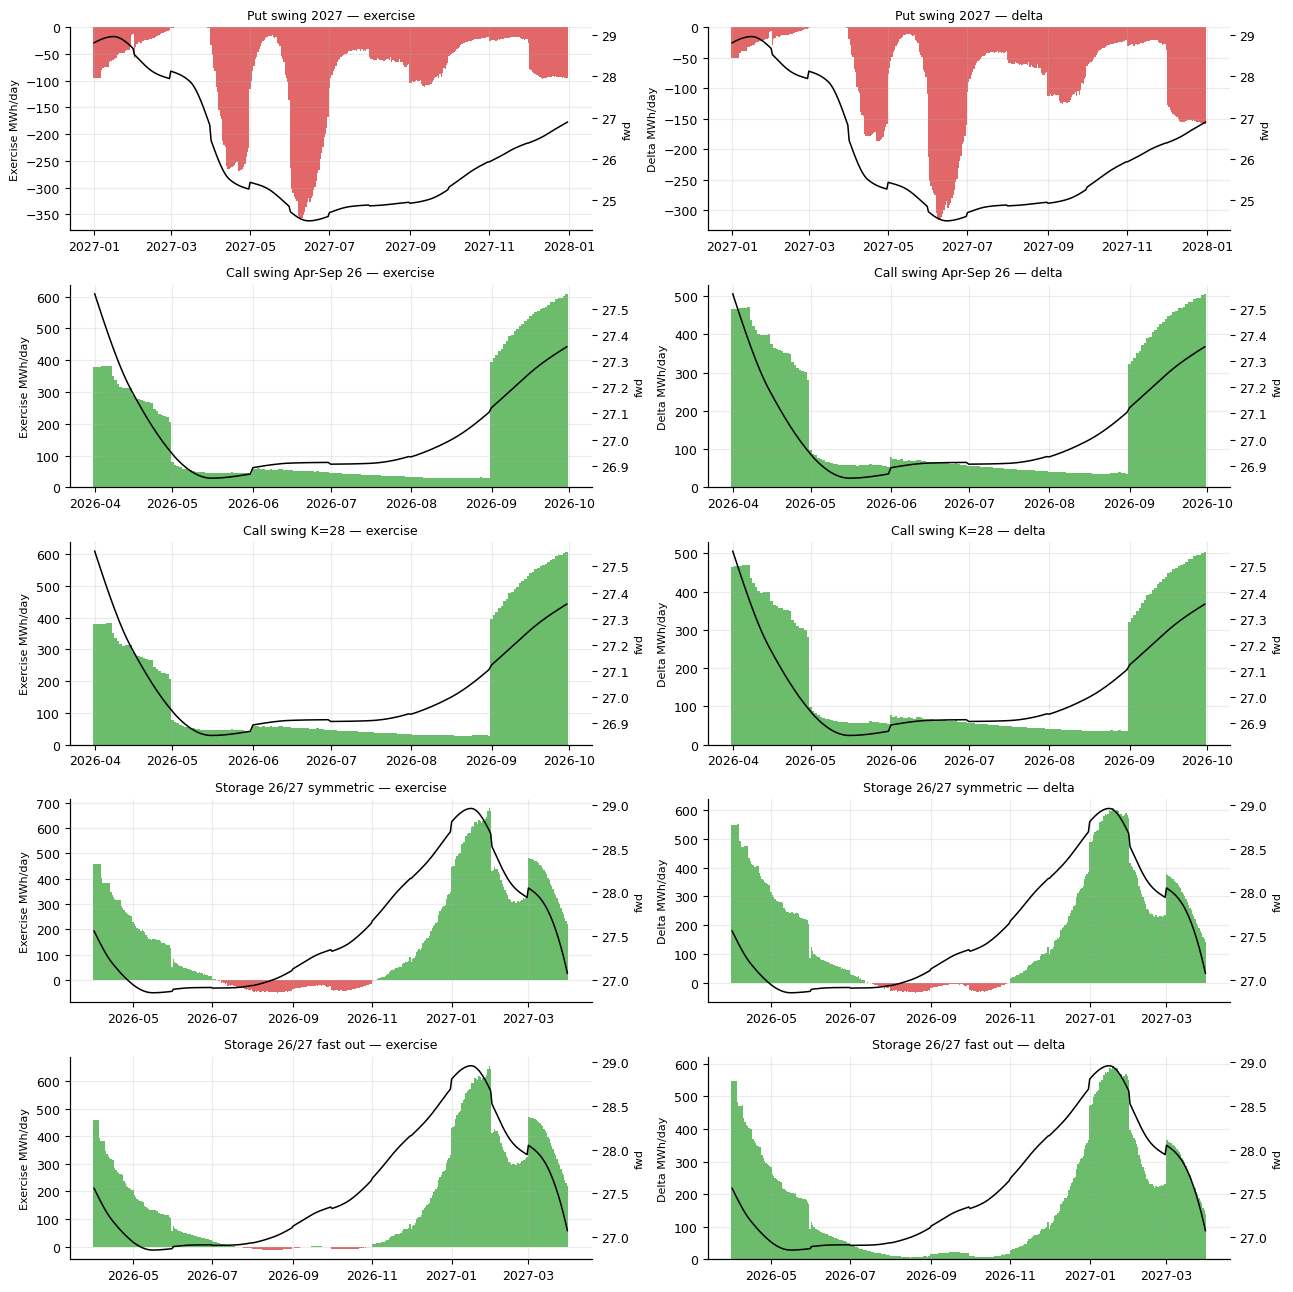

In [6]:
fig, axes = plt.subplots(len(RESULTS), 2, figsize=(13, 2.6 * len(RESULTS)), squeeze=False)
for row, (name, (s, r, g)) in enumerate(RESULTS.items()):
    idx = pd.DatetimeIndex(s.date_span[:s.n_t])
    win = slice(s.Dt, s._active)
    dates = idx[win]
    ex = pd.Series(np.asarray(s.exp_ex[:s.n_t]), index=idx).iloc[win]
    dl = pd.Series(np.asarray(s.delta[:s.n_t]), index=idx).iloc[win]
    px = pd.Series(s.fwd, index=idx).iloc[win]

    for col, (series, label, colour) in enumerate(
            [(ex, "Exercise MWh/day", "tab:blue"), (dl, "Delta MWh/day", "tab:purple")]):
        ax = axes[row][col]
        ax.bar(dates, series.where(series < 0, 0), width=1.0, color="tab:red", alpha=.7, label="buy")
        ax.bar(dates, series.where(series > 0, 0), width=1.0, color="tab:green", alpha=.7, label="sell")
        ax.set_ylabel(label, fontsize=8)
        ax.set_title(f"{name} — {label.split()[0].lower()}", fontsize=9)
        twin = ax.twinx(); twin.plot(dates, px.values, color="black", lw=1.1)
        twin.set_ylabel("fwd", fontsize=8); twin.grid(False)
plt.tight_layout(); plt.show()

In [7]:
monthly = {}
for name, (s, r, g) in RESULTS.items():
    idx = pd.DatetimeIndex(s.date_span[:s.n_t])
    dl = pd.Series(np.asarray(s.delta[:s.n_t]), index=idx).iloc[s.Dt:s._active]
    monthly[name] = dl.resample("MS").sum()

hedge = pd.DataFrame(monthly).round(0)
hedge.index = hedge.index.strftime("%b-%y")
hedge.loc["TOTAL"] = hedge.sum()
display(hedge.style.format("{:,.0f}", na_rep="—")
        .set_caption("Monthly hedge, MWh of forward to trade (negative = buy)"))
print("These are LOCAL hedge ratios and are strongly convex: a month can be several per cent")
print("off after a 1 % move in that month alone. Re-hedge; do not hold them across a big move.")

,Put swing 2027,Call swing Apr-Sep 26,Call swing K=28,Storage 26/27 symmetric,Storage 26/27 fast out
Apr-26,—,"11,561","11,561","13,104","12,006"
May-26,—,"1,971","1,971","7,698","6,466"
Jun-26,—,"2,008","2,008","2,148","2,217"
Jul-26,—,"1,516","1,516",122,805
Aug-26,—,"1,166","1,166",-878,249
Sep-26,—,"12,936","12,936",-214,580
Oct-26,—,—,—,-589,306
Nov-26,—,—,—,"1,829","1,860"
Dec-26,—,—,—,"7,340","6,848"
Jan-27,-973,—,—,"17,536","17,095"


These are LOCAL hedge ratios and are strongly convex: a month can be several per cent
off after a 1 % move in that month alone. Re-hedge; do not hold them across a big move.


## 6. Is the price tree wide enough?

`n_p` is the tree half-width. Too narrow and optionality is silently lost — at `n_p = 10` a
swing can miss ~15 % of its extrinsic value. This reprices one deal across a range so you can
see where it flattens; it should be flat well before the `n_p_full` you are using.

In [8]:
CONVERGENCE_DEAL = DEALS[0]["name"]

deal = next(d for d in DEALS if d["name"] == CONVERGENCE_DEAL)
conv = []
for n_p in (5, 10, 15, 20, 30, 45):
    s, r, g = price({**deal, "n_p_full": n_p, "run_intrinsic": False})
    conv.append({"n_p": n_p, "value EUR": g["v0"],
                 "EUR/MWh": g["v0"] / g["volume_mwh"], "secs": g["secs"]})
conv = pd.DataFrame(conv).set_index("n_p")
conv["vs n_p=45"] = conv["EUR/MWh"] - conv.loc[45, "EUR/MWh"]
display(conv.style.format({"value EUR": "{:,.0f}", "EUR/MWh": "{:.4f}",
                           "vs n_p=45": "{:+.4f}", "secs": "{:.1f}"})
        .set_caption(f"Tree-width convergence — {CONVERGENCE_DEAL}"))

,value EUR,EUR/MWh,secs,vs n_p=45
n_p,,,,
5,"-726,606",-24.2202,0.1,-0.6959
10,"-710,901",-23.6967,0.2,-0.1724
15,"-706,168",-23.5389,0.2,-0.0146
20,"-705,693",-23.5231,0.2,+0.0012
30,"-705,727",-23.5242,0.2,+0.0001
45,"-705,729",-23.5243,0.2,+0.0000


## Traps worth knowing

Each of these was a real defect found in this model; they are fixed or guarded now, but the
shapes recur.

- **`delta` is not volume.** It is the forward MWh to trade, `E[S|exercise]/F` times the
  volume, so it exceeds volume when exercise happens at high prices and falls short when it
  happens at low ones. Divide value by `exp_ex` for a per-MWh price, never by `delta`.
- **Storage rates are whole clips per day.** `inj_rate`/`wdr_rate` count clips, so anything
  slower than one clip a day needs a smaller clip — raise `clips_per_day`. Passing
  `wdr_days` instead of `wdr_rate` is refused rather than ignored.
- **The curve must reach one month past the deal.** The model carries a terminal condition
  beyond the last exercise day.
- **`n_p` is not free.** See section 6.
- **The intrinsic split breaks with a strike.** `intrinsic = profiled - flat` compares a
  strike-net value to a raw forward average, so it moves by roughly `-K`: 0.31, -9.69 and
  -27.69 EUR/MWh for K = 0, 10 and 28 on the same deal. `extrinsic` is unaffected. This
  notebook blanks the affected cells.
- **`exp_ex` is net, not gross.** For storage, injection and withdrawal can both occur on
  one date across different price states. Section 4 reports both gross figures; the net
  series is what the charts show.
- **Storage starts full by default** and must end empty. That is not obvious, and one of the
  older notebooks documents the opposite. Set `initial_inv_clips` / `terminal_inv_clips` if
  you mean something else.
- **The repricing identity carries a cost term.** `sum(DF*delta*fwd) == V0` is the zero-cost,
  zero-strike special case; with a strike or injection cost you must subtract the fixed cash
  leg, as section 3 does.
- **`sVol` and `sMR` are annualised**, and their defaults are not calibrated to anything —
  see the calibration note in `docs/MODEL-CONVENTIONS.md`.